# 🧬 Gene Expression Cancer Classification Pipeline
**Author:** Genomic Analysis Project  
**Dataset:** TCGA PanCancer RNA-Seq (via UCSC Xena)  
**Goal:** Classify cancer types from RNA-Seq gene expression data using machine learning

---

## 📌 Introduction

This notebook analyzes **pan-cancer RNA-Seq data** from the TCGA (The Cancer Genome Atlas) project.  
Each patient sample contains expression levels for ~20,000 genes measured by Illumina HiSeq RNA-Seq technology.

### Pipeline Overview:
1. **Data Loading** — Load gene expression matrix and clinical phenotype labels  
2. **Merging** — Join gene data with cancer type labels on sample ID  
3. **Cancer Mapping** — Map abbreviations to full clinical names (Arabic + English)  
4. **Data Cleaning** — Handle missing values, duplicates, and audit data integrity  
5. **EDA** — Explore distributions, variance, correlations, and outliers  
6. **Preprocessing** — Standardize features and reduce dimensionality (Variance Filter + PCA)  
7. **Visualization** — PCA scatter plots and key charts  

---

## Section 1: Data Loading
Load the RNA-Seq gene expression matrix and the clinical phenotype (cancer type) labels.
The gene file is transposed so that rows = patients and columns = genes.

In [7]:
import pandas as pd

print("Loading Gene Expression Data (this might take a few minutes)...")

# Load the gene expression file — transpose so rows = patients, columns = genes
gene_data = (
    pd.read_csv(
        "C:/Users/Dell/Downloads/EB++AdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena.gz",
        sep='\t'
    )
    .set_index('sample')
    .T
)

print(f"Gene data shape: {gene_data.shape}  (patients × genes)")

Loading Gene Expression Data (this might take a few minutes)...
Gene data shape: (11069, 20531)  (patients × genes)


In [8]:
print("Loading Phenotype Labels...")

# Load survival/phenotype file (tab-separated, uncompressed)
pheno_data = pd.read_csv(
    "C:/Users/Dell/Downloads/Survival_SupplementalTable_S1_20171025_xena_sp",
    sep='\t'
)

print(f"Phenotype data shape: {pheno_data.shape}")
print(f"Columns available: {list(pheno_data.columns[:8])} ...")

Loading Phenotype Labels...
Phenotype data shape: (12591, 34)
Columns available: ['sample', '_PATIENT', 'cancer type abbreviation', 'age_at_initial_pathologic_diagnosis', 'gender', 'race', 'ajcc_pathologic_tumor_stage', 'clinical_stage'] ...


In [9]:
# Standardize the join key to 'sampleID' in both datasets
pheno_data = pheno_data.rename(columns={'sample': 'sampleID'})
gene_data.index.name = 'sampleID'

print("Sample ID column aligned in both datasets — ready to merge.")

Sample ID column aligned in both datasets — ready to merge.


## Section 2: Merging Datasets
Perform an inner join between gene expression data and phenotype labels.
Only samples present in **both** files are kept.

In [10]:
print("Merging datasets...")

TARGET_COL = 'cancer type abbreviation'

# Inner join on sampleID — keeps only matched samples
final_df = pd.merge(
    gene_data,
    pheno_data[['sampleID', TARGET_COL]],
    on='sampleID'
)

print(f"Merged dataset shape: {final_df.shape}  (patients × [genes + label columns])")
final_df.head(3)

Merging datasets...
Merged dataset shape: (11014, 20533)  (patients × [genes + label columns])


,sampleID,100130426,100133144,100134869,10357,10431,136542,155060,26823,280660,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,cancer type abbreviation
0,TCGA-OR-A5J1-01,0.0,2.09,2.30,7.23,10.99,0.0,8.10,1.29,0.0,...,7.21,4.44,8.46,10.04,0.57,9.34,10.85,10.18,9.22,ACC
1,TCGA-OR-A5J2-01,0.0,1.88,3.32,6.36,10.35,0.0,7.65,0.00,0.0,...,8.78,5.86,8.13,11.54,5.02,10.19,11.58,10.89,9.65,ACC
2,TCGA-OR-A5J3-01,0.0,1.45,2.92,6.45,10.04,0.0,8.45,0.67,0.0,...,7.58,5.35,8.96,9.84,0.67,9.66,11.38,10.53,8.78,ACC


## Section 3: Cancer Type Mapping (Arabic + English)
Map abbreviated cancer codes (e.g. BRCA) to their full clinical names in **both English and Arabic**.
This makes the analysis more interpretable for bilingual audiences.

In [11]:
# Dictionary: abbreviation → (English name, Arabic name)
cancer_map_en = {
    'ACC': 'Adrenocortical Carcinoma',
    'BLCA': 'Bladder Urothelial Carcinoma',
    'BRCA': 'Breast Invasive Carcinoma',
    'CESC': 'Cervical Squamous Cell Carcinoma',
    'CHOL': 'Cholangiocarcinoma',
    'COAD': 'Colon Adenocarcinoma',
    'DLBC': 'Diffuse Large B-cell Lymphoma',
    'ESCA': 'Esophageal Carcinoma',
    'GBM': 'Glioblastoma Multiforme',
    'HNSC': 'Head and Neck Squamous Cell Carcinoma', 
    'KICH': 'Kidney Chromophobe',
    'KIRC': 'Kidney Renal Clear Cell Carcinoma',
    'KIRP': 'Kidney Renal Papillary Cell Carcinoma', 
    'LAML': 'Acute Myeloid Leukemia',
    'LGG': 'Brain Lower Grade Glioma',
    'LIHC': 'Liver Hepatocellular Carcinoma', 
    'LUAD': 'Lung Adenocarcinoma',
    'LUSC': 'Lung Squamous Cell Carcinoma',
    'MESO': 'Mesothelioma',
    'OV': 'Ovarian Serous Cystadenocarcinoma',
    'PAAD': 'Pancreatic Adenocarcinoma',
    'PCPG': 'Pheochromocytoma and Paraganglioma',
    'PRAD': 'Prostate Adenocarcinoma', 
    'READ': 'Rectum Adenocarcinoma',
    'SARC': 'Sarcoma',
    'SKCM': 'Skin Cutaneous Melanoma', 
    'STAD': 'Stomach Adenocarcinoma',
    'TGCT': 'Testicular Germ Cell Tumors',
    'THCA': 'Thyroid Carcinoma', 
    'THYM': 'Thymoma',
    'UCEC': 'Uterine Corpus Endometrial Carcinoma',
    'UCS': 'Uterine Carcinosarcoma', 
    'UVM': 'Uveal Melanoma'
}

cancer_map_ar = {
    'ACC': 'سرطان قشرة الأدرينال',
    'BLCA': 'سرطان المثانة', 
    'BRCA': 'سرطان الثدي',
    'CESC': 'سرطان عنق الرحم الحرشفي', 
    'CHOL': 'سرطان القنوات الصفراوية', 
    'COAD': 'سرطان القولون',
    'DLBC': 'سرطان الغدد الليمفاوية ب المساعد',
    'ESCA': 'سرطان المريء',
    'GBM': 'سرطان الدماغ - إسفنجي',
    'HNSC': 'سرطان الرأس والرقبة',
    'KICH': 'سرطان الكلى - فوبيا', 
    'KIRC': 'سرطان الكلى - خلايا صافية',
    'KIRP': 'سرطان الكلى الحليمي',
    'LAML': 'سرطان الدم النخاعي الحاد',
    'LGG': 'سرطان الدماغ - درجة منخفضة',
    'LIHC': 'سرطان الكبد',
    'LUAD': 'سرطان الرئة الغدي', 
    'LUSC': 'سرطان الرئة الحرشفي',
    'MESO': 'ورم المتوسطة',
    'OV': 'سرطان المبيض', 
    'PAAD': 'سرطان البنكرياس',
    'PCPG': 'ورم القواتم وجنيب العقد العصبية',
    'PRAD': 'سرطان البروستاتا', 
    'READ': 'سرطان المستقيم',
    'SARC': 'ساركوما (الأنسجة الضامة)', 
    'SKCM': 'سرطان الجلد - ميلانوما', 
    'STAD': 'سرطان المعدة',
    'TGCT': 'أورام الخلايا الجرثومية الخصوية', 
    'THCA': 'سرطان الغدة الدرقية',
    'THYM': 'ورم غدة التوتة',
    'UCEC': 'سرطان جسم الرحم', 
    'UCS': 'ساركوما رحمية مسرطنة', 
    'UVM': 'ميلانوما عنبية (العين)'
}
# Add two separate mapping columns: one English, one Arabic
final_df['cancer_name_en'] = final_df['cancer type abbreviation'].map(cancer_map_en)
final_df['cancer_name_ar'] = final_df['cancer type abbreviation'].map(cancer_map_ar)

# Preview the mapping
final_df[['sampleID', 'cancer type abbreviation', 'cancer_name_en', 'cancer_name_ar']].head(8)

,sampleID,cancer type abbreviation,cancer_name_en,cancer_name_ar
0,TCGA-OR-A5J1-01,ACC,Adrenocortical Carcinoma,سرطان قشرة الأدرينال
1,TCGA-OR-A5J2-01,ACC,Adrenocortical Carcinoma,سرطان قشرة الأدرينال
2,TCGA-OR-A5J3-01,ACC,Adrenocortical Carcinoma,سرطان قشرة الأدرينال
3,TCGA-OR-A5J5-01,ACC,Adrenocortical Carcinoma,سرطان قشرة الأدرينال
4,TCGA-OR-A5J6-01,ACC,Adrenocortical Carcinoma,سرطان قشرة الأدرينال
5,TCGA-OR-A5J7-01,ACC,Adrenocortical Carcinoma,سرطان قشرة الأدرينال
6,TCGA-OR-A5J8-01,ACC,Adrenocortical Carcinoma,سرطان قشرة الأدرينال
7,TCGA-OR-A5J9-01,ACC,Adrenocortical Carcinoma,سرطان قشرة الأدرينال


## Section 4: Memory Cleanup
Free up RAM by running garbage collection after heavy loading operations.

In [12]:
import gc
gc.collect() # ينظف الرام فوراً

536

## Section 5: Dataset Overview
High-level summary of the dataset dimensions before any cleaning.

In [13]:
# Separate the feature matrix from metadata columns
META_COLS = ['sampleID', 'cancer type abbreviation', 'cancer_name_en', 'cancer_name_ar']
X = final_df.drop(columns=META_COLS, errors='ignore')

# Build a quick summary table
data_summary = pd.DataFrame({
    'Metric': ['Total Patients', 'Total Genes', 'Unique Cancer Types', 'Memory Usage (MB)'],
    'Value': [
        final_df.shape[0],
        X.shape[1],
        final_df['cancer type abbreviation'].nunique(),
        f"{final_df.memory_usage(deep=True).sum() / 1e6:.2f}"
    ]
})

print("Dataset Overview:")
display(data_summary)

Dataset Overview:


,Metric,Value
0,Total Patients,11014
1,Total Genes,20531
2,Unique Cancer Types,33
3,Memory Usage (MB),1810.24


## Section 6: Data Cleaning
Check and handle: missing values (NaN), duplicate patient records, and confirm final data shape.

In [14]:
# --- Check 1: Missing values ---
null_before = final_df.isnull().sum().sum()
print(f"Missing values BEFORE cleaning : {null_before}")

# Fill all NaN with 0 (unexpressed genes treated as zero)
final_df = final_df.fillna(0)

null_after = final_df.isnull().sum().sum()
print(f"Missing values AFTER  cleaning : {null_after}")

Missing values BEFORE cleaning : 3968713
Missing values AFTER  cleaning : 0


In [15]:
# --- Check 2: Duplicate patient IDs ---
duplicate_count = final_df.duplicated(subset=['sampleID']).sum()
print(f"Duplicate sampleIDs: {duplicate_count}")

Duplicate sampleIDs: 0


In [16]:
# --- Check 3: Final shape confirmation ---
print(f"Final dataset shape after cleaning: {final_df.shape}")

Final dataset shape after cleaning: (11014, 20535)


## Section 7: Data Integrity Audit
Comprehensive quality report covering nulls, duplicates, zeros (sparsity), and negative values.

In [17]:
# Rebuild X after filling NaN
X = final_df.drop(columns=META_COLS, errors='ignore')

# Integrity audit table
integrity_report = pd.DataFrame({
    'Check': ['Missing Values', 'Duplicate SampleIDs', 'Zero-Value Cells', 'Negative Values'],
    'Result': [
        final_df.isnull().sum().sum(),
        final_df.duplicated(subset=['sampleID']).sum(),
        int((X == 0).sum().sum()),
        int((X < 0).sum().sum())          # RNA-Seq values should not be negative
    ]
})

print("Data Integrity Audit Report:")
display(integrity_report)

Data Integrity Audit Report:


,Check,Result
0,Missing Values,0
1,Duplicate SampleIDs,0
2,Zero-Value Cells,32005675
3,Negative Values,1241991


In [18]:
# Sparsity = proportion of zero values across the entire gene matrix
zero_percentage = (X == 0).mean().mean() * 100
print(f"Sparsity: {zero_percentage:.2f}% of the gene matrix contains zeros.")

Sparsity: 14.15% of the gene matrix contains zeros.


## Section 8: Exploratory Data Analysis (EDA)

In [20]:
# Percentage distribution of cancer types
dist_df = (
    final_df['cancer type abbreviation']
    .value_counts(normalize=True)
    .reset_index()
)
dist_df.columns = ['Cancer Type', 'Percentage']
dist_df['Percentage'] = dist_df['Percentage'].map(lambda x: f"{x*100:.2f}%")

print("Top 10 Cancer Types by Percentage:")
display(dist_df.head(10))

Top 10 Cancer Types by Percentage:


,Cancer Type,Percentage
0,BRCA,11.03%
1,KIRC,5.50%
2,LUAD,5.23%
3,THCA,5.19%
4,HNSC,5.14%
5,UCEC,5.04%
6,LUSC,5.01%
7,PRAD,4.99%
8,LGG,4.80%
9,COAD,4.47%


### 8.2 Descriptive Statistics
Summary statistics (mean, std, min, max) for a sample of genes.

In [21]:
# Stats for first 5 genes — a quick sanity check on data scale
stats_table = X.iloc[:, :5].describe().T
print("Descriptive Statistics — First 5 Genes:")
display(stats_table)

Descriptive Statistics — First 5 Genes:


,count,mean,std,min,25%,50%,75%,max
100130426,11014.0,0.024768,0.137731,-0.14,0.00,0.00,0.00,4.25
100133144,11014.0,3.011149,1.403279,-1.08,2.15,3.14,4.00,7.56
100134869,11014.0,3.205047,1.191814,-1.05,2.48,3.27,4.00,8.66
10357,11014.0,7.034835,0.912901,0.00,6.43,6.96,7.59,10.96
10431,11014.0,9.839009,0.551859,7.87,9.47,9.82,10.20,12.74


### 8.4 Correlation Matrix of Top Variable Genes
Studying pairwise correlations among the most variable genes. Highly correlated genes may be redundant — useful insight for dimensionality reduction.

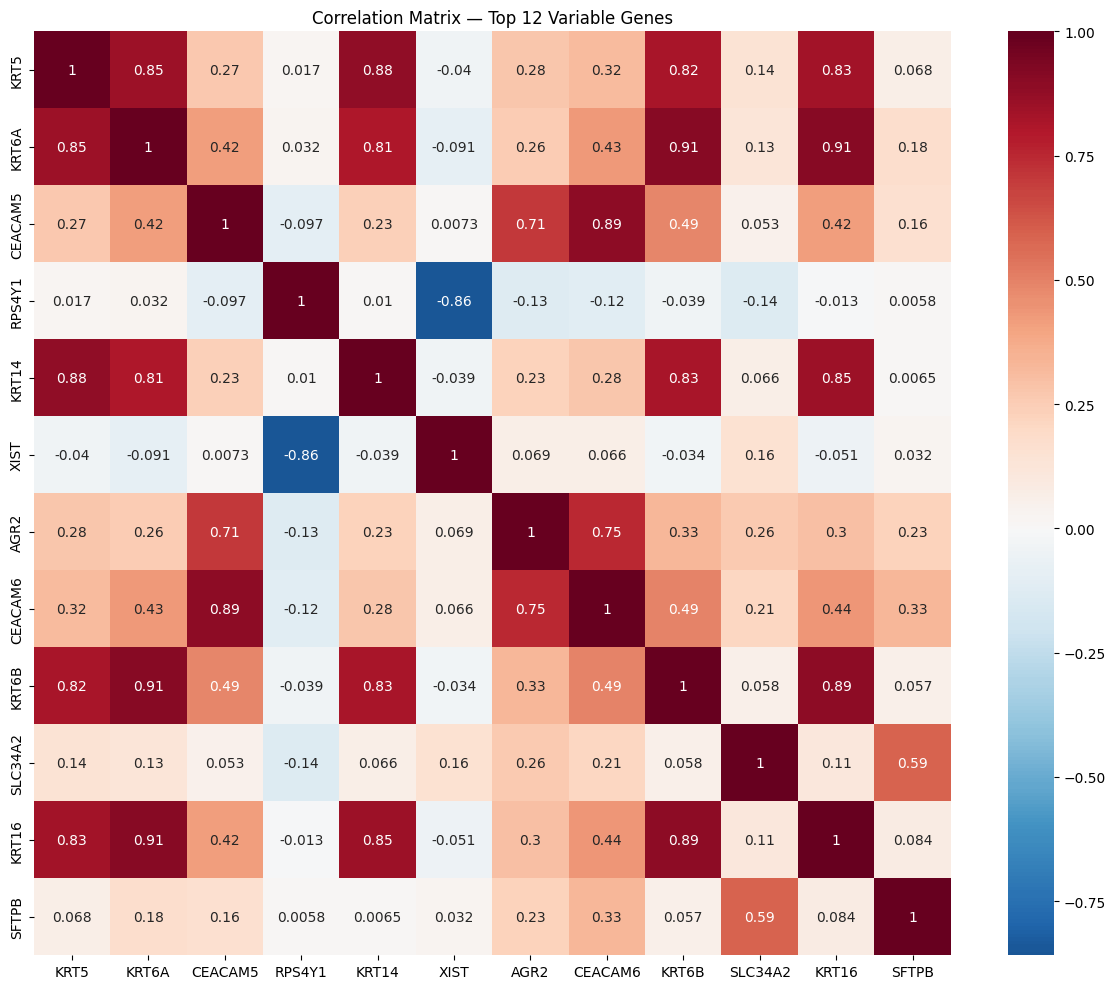

In [23]:
# Extended correlation heatmap — top 12 variable genes
top_genes_12 = X.std().sort_values(ascending=False).head(12).index
corr_mat_12 = X[top_genes_12].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_mat_12, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Matrix — Top 12 Variable Genes')
plt.tight_layout()
plt.show()

In [24]:
# 1. تحديد مجموعات البيانات
brca_data = final_df[final_df['cancer type abbreviation'] == 'BRCA'][X.columns]
luad_data = final_df[final_df['cancer type abbreviation'] == 'LUAD'][X.columns]

# 2. حساب متوسط التعبير لكل جين في كل نوع
brca_means = brca_data.mean().sort_values(ascending=False)
luad_means = luad_data.mean().sort_values(ascending=False)

# 3. تجميع أهم الجينات في جدول واحد للمقارنة
comparison_table = pd.DataFrame({
    'Top Genes in BRCA': brca_means.head(10).index,
    'BRCA Mean Exp': brca_means.head(10).values,
    'Top Genes in LUAD': luad_means.head(10).index,
    'LUAD Mean Exp': luad_means.head(10).values
})

# 4. إضافة عمود الفرق (اختياري لزيادة التحليل)
print("Top 10 Expressed Genes: BRCA vs LUAD Comparison Table")
display(comparison_table.style.background_gradient(cmap='YlGnBu'))

Top 10 Expressed Genes: BRCA vs LUAD Comparison Table


,Top Genes in BRCA,BRCA Mean Exp,Top Genes in LUAD,LUAD Mean Exp
0,ACTB,16.432222,ACTB,16.813472
1,EEF1A1,16.295424,FTL,16.310608
2,COL1A1,16.227827,SFTPB,16.152639
3,ACTG1,16.099226,EEF1A1,16.113333
4,COL1A2,15.885062,ACTG1,16.064062
5,FN1,15.838938,CD74,16.061406
6,COL3A1,15.767926,ADAM6,15.946875
7,EEF2,15.453383,B2M,15.847240
8,GAPDH,15.443440,TPT1,15.817622
9,TPT1,15.410963,FN1,15.604844


## Section 9: Preprocessing

### 9.1 Feature Standardization
Convert gene values to zero mean and unit variance (StandardScaler).
This prevents high-magnitude genes from dominating distance-based methods like PCA.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Standardization complete — Mean ≈ 0, Std ≈ 1")
print(f"X_scaled shape: {X_scaled.shape}")

Standardization complete — Mean ≈ 0, Std ≈ 1
X_scaled shape: (11014, 20531)


### 9.2 Dimensionality Reduction — Step 1: Variance Thresholding
Remove genes that barely change across patients (near-zero variance = low information).

In [26]:
from sklearn.feature_selection import VarianceThreshold

# Remove genes with variance below threshold
selector = VarianceThreshold(threshold=0.1)
X_reduced = selector.fit_transform(X_scaled)

print(f"Before Variance Filter : {X_scaled.shape[1]:,} genes")
print(f"After  Variance Filter : {X_reduced.shape[1]:,} genes")

Before Variance Filter : 20,531 genes
After  Variance Filter : 20,312 genes


### 9.3 Dimensionality Reduction — Step 2: PCA (95% Variance)
Compress the remaining genes into Principal Components that collectively retain 95% of the data's variance.

In [27]:
from sklearn.decomposition import PCA

from sklearn.decomposition import IncrementalPCA

# سنحدد عدد مكونات ثابت (مثلاً 500 مكون) لتقليل الضغط
# أو يمكنك استخدام PCA العادي مع solver مختلف 
# إليكِ الطريقة الأضمن للجهاز:
pca_full = PCA(n_components=500, svd_solver='auto') 
X_pca_full = pca_full.fit_transform(X_reduced)

print(f"PCA completed! Reduced to {X_pca_full.shape[1]} components.")

print(f"PCA completed successfully!")
print(f"Reduced to {X_pca_full.shape[1]} components.")
print(f"Original genes         : {X_scaled.shape[1]:,}")
print(f"After Variance Filter  : {X_reduced.shape[1]:,}")
print(f"After PCA (95% var)    : {X_pca_full.shape[1]:,} components")

PCA completed! Reduced to 500 components.
PCA completed successfully!
Reduced to 500 components.
Original genes         : 20,531
After Variance Filter  : 20,312
After PCA (95% var)    : 500 components


## Section 10: Visualization — PCA Scatter Plot
Reduce data to 2 components for visual exploration. Clusters of the same color indicate that patients with the same cancer type share similar gene expression profiles.

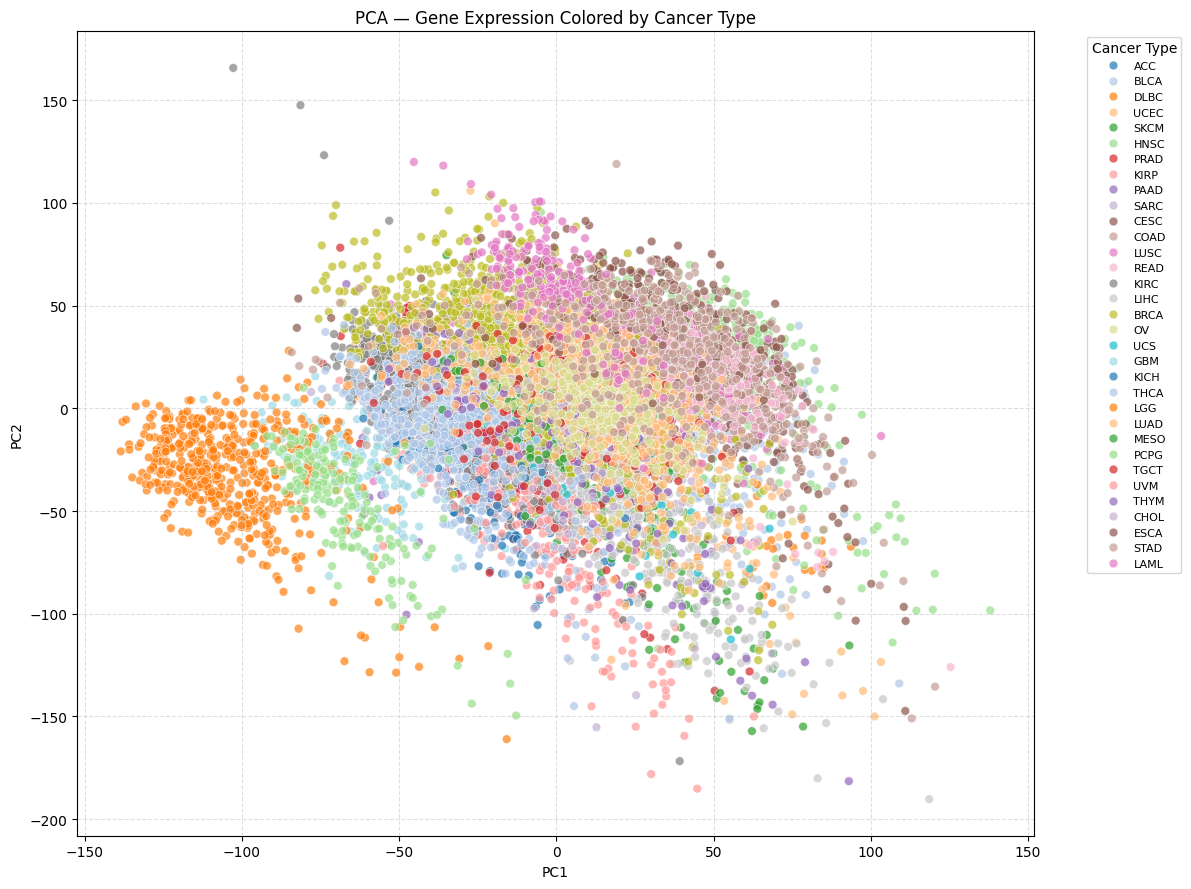

Observation: Samples of the same cancer type tend to cluster together,
confirming that gene expression profiles are cancer-type-specific.


In [28]:
# 2-component PCA for 2D visualization only (not for modeling)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

y = final_df['cancer type abbreviation']

# Build a DataFrame for Seaborn
pca_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
pca_df['Cancer Type'] = y.values

# Scatter plot colored by cancer type
plt.figure(figsize=(12, 9))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='Cancer Type',
    palette='tab20',
    s=40, alpha=0.7
)
plt.title('PCA — Gene Expression Colored by Cancer Type')
plt.legend(title='Cancer Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("Observation: Samples of the same cancer type tend to cluster together,")
print("confirming that gene expression profiles are cancer-type-specific.")

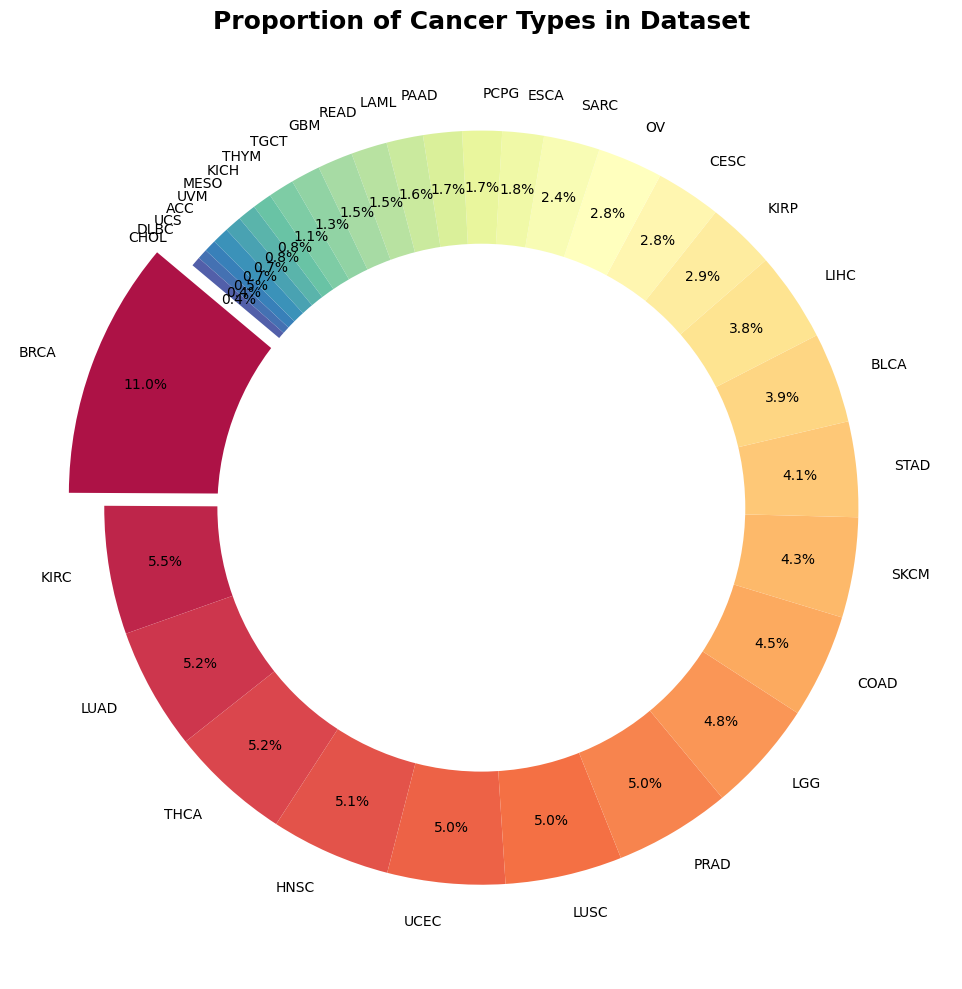

In [32]:
cancer_counts = final_df['cancer type abbreviation'].value_counts()
colors = sns.color_palette('pastel')[0:len(cancer_counts)]

plt.figure(figsize=(10, 10))
plt.pie(
    cancer_counts, 
    labels=cancer_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette("Spectral", len(cancer_counts)),
    pctdistance=0.85,
    explode=[0.1 if i == 0 else 0 for i in range(len(cancer_counts))] # تفجير أكبر شريحة
)

# إضافة الدائرة البيضاء في المنتصف لتحويلها لـ Donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proportion of Cancer Types in Dataset', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

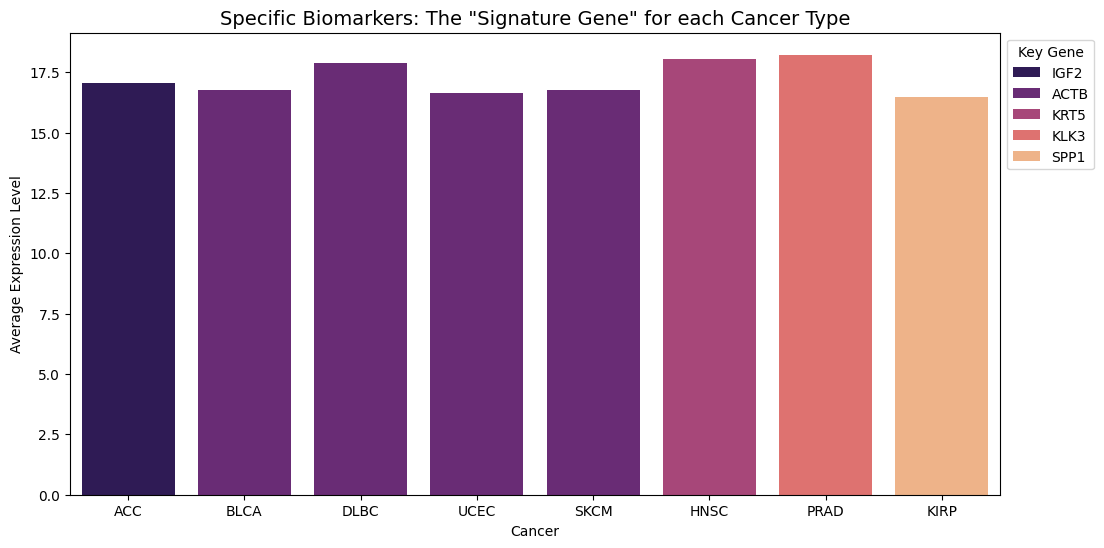

In [39]:
# كود لاستخراج أقوى جين لكل نوع سرطان ورسمه
top_markers = []
for cancer in final_df['cancer type abbreviation'].unique()[:8]: # سنأخذ أول 8 أنواع للتبسيط
    # نجد الجين الذي يمتلك أعلى متوسط في هذا النوع مقارنة بالبقية
    avg_exp = final_df[final_df['cancer type abbreviation'] == cancer][X.columns].mean()
    best_gene = avg_exp.idxmax()
    top_markers.append({'Cancer': cancer, 'Gene': best_gene, 'Expression': avg_exp.max()})

markers_df = pd.DataFrame(top_markers)

plt.figure(figsize=(12, 6))
sns.barplot(data=markers_df, x='Cancer', y='Expression', hue='Gene', palette='magma')
plt.title('Specific Biomarkers: The "Signature Gene" for each Cancer Type', fontsize=14)
plt.ylabel('Average Expression Level')
plt.legend(title='Key Gene', bbox_to_anchor=(1, 1))
plt.show()

###  High-Variance Gene Analysis
Genes with the highest standard deviation vary the most across patients — prime candidates for discriminating cancer types.

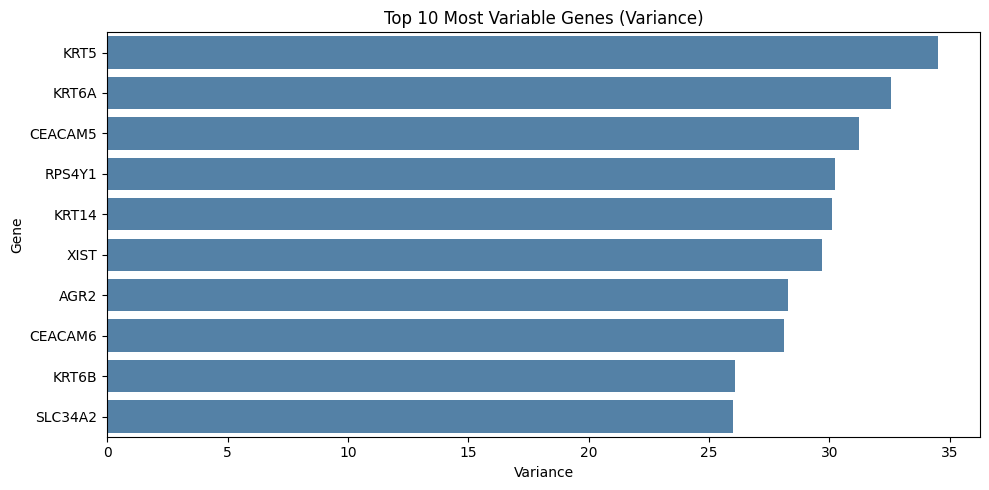

In [41]:
# Top 10 genes by variance
variances = X.var().sort_values(ascending=False).head(10)
var_df = pd.DataFrame({'Gene': variances.index, 'Variance': variances.values})

plt.figure(figsize=(10, 5))
sns.barplot(data=var_df, x='Variance', y='Gene', color='steelblue')
plt.title('Top 10 Most Variable Genes (Variance)')
plt.tight_layout()
plt.show()

### 8.1 Cancer Type Distribution
Count how many patients belong to each cancer type. Helps detect class imbalance.

C:\Users\Dell\AppData\Local\Temp\ipykernel_8864\505082434.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cancer_counts, x='Cancer Type', y='Patient Count', palette='magma')


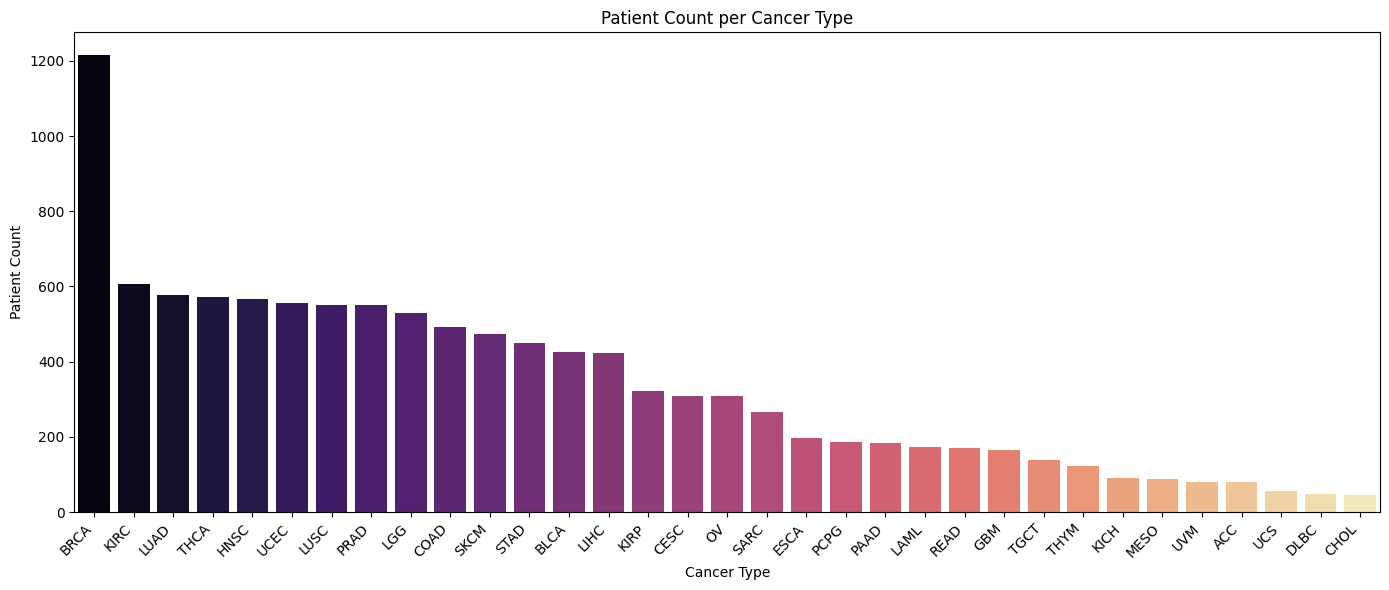

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Frequency table
cancer_counts = (
    final_df['cancer type abbreviation']
    .value_counts()
    .reset_index()
)
cancer_counts.columns = ['Cancer Type', 'Patient Count']

# Bar chart of patient counts per cancer type
plt.figure(figsize=(14, 6))
sns.barplot(data=cancer_counts, x='Cancer Type', y='Patient Count', palette='magma')
plt.title('Patient Count per Cancer Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Section 11: Label Encoding
Convert cancer type names to integer labels. Postponed until after EDA to preserve readable names in all plots above.

In [44]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode cancer type strings → integer labels
y_encoded = le.fit_transform(final_df['cancer type abbreviation'])
final_df['cancer_label'] = y_encoded

# Print the full encoding map
encoding_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Cancer Type → Integer Label Mapping:")
for abbrev, code in encoding_map.items():
    en = cancer_map_en.get(abbrev, 'Unknown')
    ar = cancer_map_ar.get(abbrev, 'غير معروف')
    print(f"  {abbrev:6s} = {code:2d}  |  {en}  |  {ar}")

print(f"\nTotal classes : {len(le.classes_)}")
print(f"Shape of y    : {y_encoded.shape}")
print(f"Shape of X_pca: {X_pca_full.shape}")

Cancer Type → Integer Label Mapping:
  ACC    =  0  |  Adrenocortical Carcinoma  |  سرطان قشرة الأدرينال
  BLCA   =  1  |  Bladder Urothelial Carcinoma  |  سرطان المثانة
  BRCA   =  2  |  Breast Invasive Carcinoma  |  سرطان الثدي
  CESC   =  3  |  Cervical Squamous Cell Carcinoma  |  سرطان عنق الرحم الحرشفي
  CHOL   =  4  |  Cholangiocarcinoma  |  سرطان القنوات الصفراوية
  COAD   =  5  |  Colon Adenocarcinoma  |  سرطان القولون
  DLBC   =  6  |  Diffuse Large B-cell Lymphoma  |  سرطان الغدد الليمفاوية ب المساعد
  ESCA   =  7  |  Esophageal Carcinoma  |  سرطان المريء
  GBM    =  8  |  Glioblastoma Multiforme  |  سرطان الدماغ - إسفنجي
  HNSC   =  9  |  Head and Neck Squamous Cell Carcinoma  |  سرطان الرأس والرقبة
  KICH   = 10  |  Kidney Chromophobe  |  سرطان الكلى - فوبيا
  KIRC   = 11  |  Kidney Renal Clear Cell Carcinoma  |  سرطان الكلى - خلايا صافية
  KIRP   = 12  |  Kidney Renal Papillary Cell Carcinoma  |  سرطان الكلى الحليمي
  LAML   = 13  |  Acute Myeloid Leukemia  |  سرطان الدم ا